# Определение стоимости недвижимости из набора данных California Housing

Учебный курс "[Программирование глубоких нейронных сетей на Python](https://openedu.ru/course/urfu/PYDNN/)".


## Подготовка данных для обучения сети


**Загружаем набор данных**

Набор данных California Housing доступен через библиотеку scikit-learn. Разделим его на обучающий и тестовый наборы.


In [112]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

In [120]:
housing = fetch_california_housing()

X = housing.data
y = housing.target

In [115]:
housing.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [123]:
print(housing['DESCR'])

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

    :Number of Instances: 20640

    :Number of Attributes: 8 numeric, predictive attributes and the target

    :Attribute Information:
        - MedInc        median income in block group
        - HouseAge      median house age in block group
        - AveRooms      average number of rooms per household
        - AveBedrms     average number of bedrooms per household
        - Population    block group population
        - AveOccup      average number of household members
        - Latitude      block group latitude
        - Longitude     block group longitude

    :Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived

In [116]:
import pandas as pd
import seaborn as sns
frame = pd.DataFrame(X, columns = housing.feature_names)
frame.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [105]:
y.min(), y.max()

(0.14999, 5.00001)

## Визуализация набора данных


Составим таблицу с признаками и добавим целевую переменную (стоимость дома), чтобы понять, с чем имеем дело.


In [124]:
# Объединяем признаки и целевую переменную в одну таблицу
df = pd.DataFrame(X, columns=housing.feature_names)
df['MedHouseVal'] = y
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


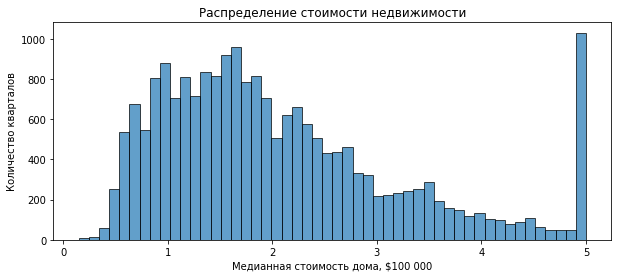

In [125]:
# Распределение целевой переменной (медианная стоимость дома в квартале)
plt.figure(figsize=(10, 4))
plt.hist(df['MedHouseVal'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Медианная стоимость дома, $100 000')
plt.ylabel('Количество кварталов')
plt.title('Распределение стоимости недвижимости')
plt.show()


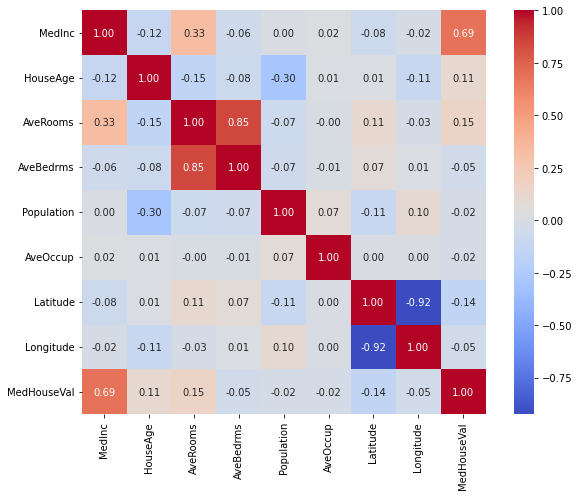

In [126]:
# Матрица корреляций признаков и целевой переменной
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.tight_layout()
plt.show()

Для наиболее информативных признаков построим графики зависимости цены:


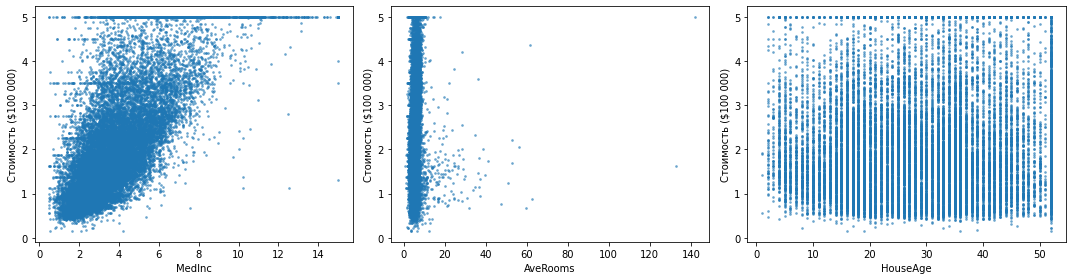

In [127]:
# Зависимость цены от наиболее коррелированных признаков
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feat in zip(axes, ['MedInc', 'AveRooms', 'HouseAge']):
    ax.scatter(df[feat], df['MedHouseVal'], s=3, alpha=0.5)
    ax.set_xlabel(feat)
    ax.set_ylabel('Стоимость ($100 000)')
plt.tight_layout()
plt.show()


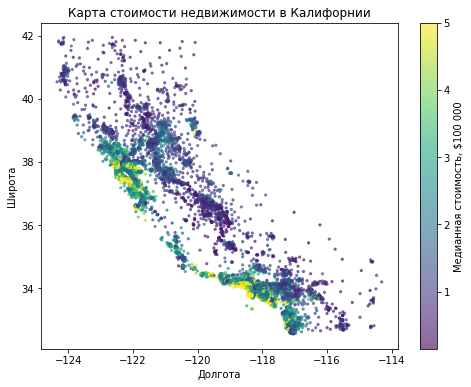

In [128]:
# Географическое распределение стоимости недвижимости
plt.figure(figsize=(8, 6))
sc = plt.scatter(df['Longitude'], df['Latitude'], c=df['MedHouseVal'],
                 cmap='viridis', s=5, alpha=0.6)
plt.colorbar(sc, label='Медианная стоимость, $100 000')
plt.xlabel('Долгота')
plt.ylabel('Широта')
plt.title('Карта стоимости недвижимости в Калифорнии')
plt.show()


In [129]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
print(f"Обучающий набор: {X_train.shape}, {y_train.shape}")
print(f"Тестовый набор: {X_test.shape}, {y_test.shape}")

Обучающий набор: (15480, 8), (15480,)
Тестовый набор: (5160, 8), (5160,)


**Размерность данных**


In [130]:
X_train.shape, y_train.shape

((15480, 8), (15480,))

In [131]:
X_train[0]

array([   4.2143    ,   37.        ,    5.28823529,    0.97352941,
        860.        ,    2.52941176,   33.81      , -118.12      ])

Просматриваем данные


In [132]:
y_train[:5]

array([2.285, 2.799, 1.83 , 4.658, 1.5  ])

**Названия столбцов**

- MedInc: median income in block group
- HouseAge: median house age in block group
- AveRooms: average number of rooms per household
- AveBedrms: average number of bedrooms per household
- Population: block group population
- AveOccup: average number of household members
- Latitude: block group latitude
- Longitude: block group longitude

Целевая переменная - средняя стоимость недвижимости в квартале (в сотнях тысяч долларов).


**Предварительная обработка данных**


In [133]:
mean

array([-1.16526082e-15, -1.65256841e-16,  8.64890273e-15, -1.20910621e-14,
       -5.89680472e-17, -4.06050803e-17,  7.07835599e-14, -2.67487181e-13])

Нормализация данных для обучения


In [134]:
# Нормализация данных
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std
X_test

array([[-1.15411223, -0.28514924, -0.51346718, ...,  0.06447083,
         0.19367548,  0.28652736],
       [-0.70756701,  0.11133247, -0.16361884, ..., -0.03570466,
        -0.23746391,  0.06179445],
       [-0.20917611,  1.855852  , -0.6022714 , ..., -0.14606959,
         1.00909127, -1.4264368 ],
       ...,
       [-0.89908611,  0.66640687, -0.89340574, ...,  0.12360294,
        -0.76232924,  0.66108221],
       [ 1.58036659, -1.79177974,  0.80393479, ..., -0.04836253,
         1.34181841, -0.73725589],
       [ 1.44652384,  0.58711053,  0.12349223, ..., -0.04755791,
        -0.82325111,  0.5911653 ]])

Масштабирование целевой переменной

Целевая переменная выражена в сотнях тысяч долларов. Для удобства разделим её на 100000, чтобы значения были того же порядка, что и признаки.


In [13]:
# y_train = y_train / 100000
# y_test = y_test / 100000
# y_train[:5]

In [135]:
X_train.shape

(15480, 8)

**Создаем тензоры и загрузчики данных**


In [136]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

In [137]:
X_train_t.shape, y_train_t.shape

(torch.Size([15480, 8]), torch.Size([15480]))

In [142]:
batch_size = 32

# Для регрессии используем собственный набор данных
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

# Для проверочного набора выделим 20% обучающего
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = torch.utils.data.random_split(
    train_dataset, [train_size, val_size]
)

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

## Создаем модель


In [178]:
class RegressionNet(nn.Module):
    def __init__(self, n_features=8):
        super().__init__()
        # Входной слой + скрытый слой + выходной слой
        self.net = nn.Sequential(
            nn.Linear(n_features, 100),  # Входной слой
            nn.Tanh(),
            nn.Linear(100, 50),          # Скрытый слой
            nn.Tanh(),
            nn.Linear(50, 1),           # Выходной слой, без функции активации
            nn.ReLU()
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


In [179]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используем устройство: {device}")
model = RegressionNet().to(device)
print(model)

Используем устройство: cpu
RegressionNet(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=100, bias=True)
    (1): Tanh()
    (2): Linear(in_features=100, out_features=50, bias=True)
    (3): Tanh()
    (4): Linear(in_features=50, out_features=1, bias=True)
    (5): ReLU()
  )
)


**Задаем функцию ошибки и оптимизатор**

Для задачи регрессии используется среднеквадратичная ошибка `nn.MSELoss()`.


In [180]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

## Обучаем модель


In [181]:
def train_reg(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    train_loss, train_mae = 0, 0
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X.size(0)
        train_mae += torch.abs(pred - y).sum().item()
    return train_loss / size, train_mae / size

In [182]:
def test_reg(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    model.eval()
    test_loss, test_mae = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item() * X.size(0)
            test_mae += torch.abs(pred - y).sum().item()
    return test_loss / size, test_mae / size

**Обучаем модель**


In [183]:
epochs = 200
history_train_mae, history_val_mae = [], []
history_train_loss, history_val_loss = [], []

for t in range(epochs):
    tr_loss, tr_mae = train_reg(train_loader, model, loss_fn, optimizer)
    val_loss, val_mae = test_reg(val_loader, model, loss_fn)
    history_train_mae.append(tr_mae)
    history_val_mae.append(val_mae)
    history_train_loss.append(tr_loss)
    history_val_loss.append(val_loss)
    if (t + 1) % 10 == 0:
        print(f"Эпоха {t+1:>3}/{epochs} \tОшибка: {tr_loss:>8f} \tMAE: {tr_mae*100000:>8.0f} \tВал. MAE: {val_mae*100000:>8.0f}")


Эпоха  10/200 	Ошибка: 0.328714 	MAE:    39660 	Вал. MAE:    39817
Эпоха  20/200 	Ошибка: 0.302651 	MAE:    37955 	Вал. MAE:    37382
Эпоха  30/200 	Ошибка: 0.284431 	MAE:    36587 	Вал. MAE:    36185
Эпоха  40/200 	Ошибка: 0.269911 	MAE:    35472 	Вал. MAE:    35030
Эпоха  50/200 	Ошибка: 0.257811 	MAE:    34580 	Вал. MAE:    34667
Эпоха  60/200 	Ошибка: 0.250928 	MAE:    34142 	Вал. MAE:    34495
Эпоха  70/200 	Ошибка: 0.244515 	MAE:    33649 	Вал. MAE:    35809
Эпоха  80/200 	Ошибка: 0.239430 	MAE:    33347 	Вал. MAE:    34193
Эпоха  90/200 	Ошибка: 0.233391 	MAE:    32960 	Вал. MAE:    34440
Эпоха 100/200 	Ошибка: 0.227423 	MAE:    32483 	Вал. MAE:    34211
Эпоха 110/200 	Ошибка: 0.223145 	MAE:    32178 	Вал. MAE:    34598
Эпоха 120/200 	Ошибка: 0.220816 	MAE:    32013 	Вал. MAE:    34015
Эпоха 130/200 	Ошибка: 0.215502 	MAE:    31779 	Вал. MAE:    34282
Эпоха 140/200 	Ошибка: 0.211165 	MAE:    31572 	Вал. MAE:    35087
Эпоха 150/200 	Ошибка: 0.207497 	MAE:    31256 	Вал. MAE:    3

### Визуализация прогресса обучения


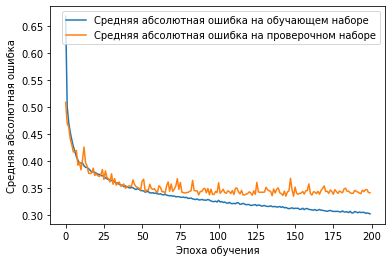

In [184]:
plt.plot(history_train_mae, label='Средняя абсолютная ошибка на обучающем наборе')
plt.plot(history_val_mae, label='Средняя абсолютная ошибка на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Средняя абсолютная ошибка')
plt.legend()
plt.show()

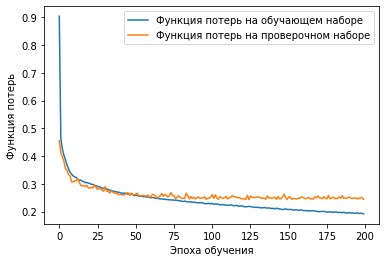

In [185]:
plt.plot(history_train_loss, label='Функция потерь на обучающем наборе')
plt.plot(history_val_loss, label='Функция потерь на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Функция потерь')
plt.legend()
plt.show()

## Оценка качества обучения


Проверка качества работы на наборе данных для тестирования


In [186]:
test_loss, test_mae = test_reg(test_loader, model, loss_fn)
print(f"Средняя абсолютная ошибка на тестовых данных: {test_mae*100000} долларов")

Средняя абсолютная ошибка на тестовых данных: 34366.25057412672 долларов


In [187]:
test_mae

0.3436625057412672

In [188]:
X_test_t.shape

torch.Size([5160, 8])

## Предсказание на тестовых данных


In [189]:
model.eval()
with torch.no_grad():
    predictions = model(X_test_t.to(device))
predictions = predictions.cpu().numpy()
predictions[:5]

array([0.44264007, 0.7398787 , 5.1077456 , 2.4109004 , 2.5114875 ],
      dtype=float32)

In [190]:
predictions.min()*100000, predictions.max()*100000

(0.0, 562780.8094024658)

In [191]:
y_test[:10]

array([0.477  , 0.458  , 5.00001, 2.186  , 2.78   , 1.587  , 1.982  ,
       1.575  , 3.4    , 4.466  ])

In [192]:
predictions

array([0.44264007, 0.7398787 , 5.1077456 , ..., 1.4233094 , 2.8851986 ,
       4.3865385 ], dtype=float32)

In [193]:
y_test

array([0.477  , 0.458  , 5.00001, ..., 1.177  , 2.631  , 4.815  ])

In [194]:
y_test.min(), y_test.max()

(0.14999, 5.00001)

In [195]:
predictions.min(), predictions.max()

(0.0, 5.627808)